<a href="https://colab.research.google.com/github/SathishDissanayaka/statistical-analysis-neural-network-depth/blob/main/INFERENTIALtesting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Inferential Analysis (Preprocessed Data): Does Training Deeper Models Increase Representational Capacity?

This notebook replicates the full inferential analysis on the **preprocessed** dataset produced by `01_preprocessing.py`.  
The preprocessing pipeline already handled:
- Removal of optimisation failures
- Feature engineering (`gen_gap`, `epoch_fraction`, `total_flops`, `loss_drop_10_to_final`, `log_n_params`, `log_total_flops`, `depth_per_param`)
- Ordinal categoricals (`depth_group`, `corruption_group`)
- Regime encoding (`regime_code`) and depth one-hot dummies
- Missingness indicators (`missing_ep30`, `missing_ep60`)

**Research question:** Does depth increase representational capacity (memorisation at `corruption=1.0`) when parameter count is held fixed?

**Analysis roadmap:**
1. Load preprocessed CSV & quick validation
2. Assumption checks (Shapiro-Wilk normality, Levene homogeneity of variance) + Q-Q plots
3. Kruskal-Wallis tests (primary non-parametric ANOVA equivalent)
4. Post-hoc pairwise comparisons (Dunn's test with Holm-Bonferroni correction)
5. OLS regression controlling for confounders (`log_n_params`, `param_err_pct`)
6. Supporting tests: Regime comparison & budget interaction
7. Summary table of all inferential results

---

In [ ]:
# Install missing dependency
!pip install scikit-posthocs

In [ ]:
# -*- coding: utf-8 -*-
"""inferential.ipynb

Automatically generated by Colab.

Original file is located at
    https://colab.research.google.com/drive/16gP9vegVFKaEEw_VtUVCHCRAvoNd5iR9
"""

# ## 0. Setup & Imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from scipy import stats
from scipy.stats import kruskal, shapiro, levene, mannwhitneyu, spearmanr
try:
    import scikit_posthocs as sp
except ImportError as exc:
    raise ImportError(
        'Missing dependency: scikit-posthocs. Install it in your environment and re-run.'
    ) from exc

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.outliers_influence import variance_inflation_factor

pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 30)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 5)

DEPTH_ORDER      = [2, 4, 6, 8, 12, 16]
CORRUPTION_LEVELS = [0.0, 0.6, 1.0]
PALETTE = sns.color_palette('muted', len(DEPTH_ORDER))

print('Imports OK')

Imports OK


---
## 1. Load Preprocessed Data

Point `FILE_PATH` at the CSV exported by `01_preprocessing.py` (`data_preprocessed.csv`).  
The file already contains all engineered features — no re-derivation needed here.

In [ ]:
# ── Local path to preprocessed CSV ───────────────────────────────────────────
FILE_PATH = '/content/data_preprocessed.csv'

df = pd.read_csv(FILE_PATH)

# Restore ordered categoricals (lost on CSV round-trip)
df['depth_group']      = pd.Categorical(df['depth'],      categories=DEPTH_ORDER,       ordered=True)
df['corruption_group'] = pd.Categorical(df['corruption'], categories=CORRUPTION_LEVELS, ordered=True)

# Ensure regime_code exists for regression models
if 'regime_code' not in df.columns:
    df['regime_code'] = (df['regime'] == 'fixed_width').astype(int)

print(f'Loaded {len(df):,} rows × {df.shape[1]} columns')
print(f'Columns: {df.columns.tolist()}')
df.head(3)

Loaded 1,800 rows × 31 columns
Columns: ['depth', 'width', 'n_params', 'seed', 'final_train_acc', 'final_test_acc', 'final_train_loss', 'actual_epochs', 'flops_per_epoch', 'optimization_failure', 'loss_ep10', 'loss_ep20', 'loss_ep30', 'loss_ep50', 'loss_ep70', 'loss_ep90', 'regime', 'budget', 'fixed_w', 'corruption', 'param_err_pct', 'gen_gap', 'epoch_fraction', 'total_flops', 'loss_drop_10_to_final', 'depth_group', 'corruption_group', 'log_n_params', 'log_total_flops', 'depth_per_param', 'regime_code']


,depth,width,n_params,seed,final_train_acc,final_test_acc,final_train_loss,actual_epochs,flops_per_epoch,optimization_failure,loss_ep10,loss_ep20,loss_ep30,loss_ep50,loss_ep70,...,regime,budget,fixed_w,corruption,param_err_pct,gen_gap,epoch_fraction,total_flops,loss_drop_10_to_final,depth_group,corruption_group,log_n_params,log_total_flops,depth_per_param,regime_code
0,2,24,19786,42,0.9965,0.8192,0.0296,100,294480000,False,0.3719,0.2737,0.1808,0.0974,0.0475,...,iso_param,20000.0000,NaN,0.0000,1.0700,0.1773,1.0000,29448000000,0.3423,2,0.0000,4.2964,10.4691,0.0001,0
1,2,24,19786,123,0.9941,0.8276,0.0343,100,294480000,False,0.3830,0.2539,0.1922,0.0959,0.0517,...,iso_param,20000.0000,NaN,0.0000,1.0700,0.1665,1.0000,29448000000,0.3486,2,0.0000,4.2964,10.4691,0.0001,0
2,2,24,19786,7,0.9940,0.8222,0.0389,100,294480000,False,0.3842,0.2561,0.2104,0.1223,0.0563,...,iso_param,20000.0000,NaN,0.0000,1.0700,0.1718,1.0000,29448000000,0.3453,2,0.0000,4.2964,10.4691,0.0001,0


In [ ]:
# ── Quick validation: confirm preprocessing was applied ─────────────────────
assert 'gen_gap'               in df.columns, 'gen_gap missing — wrong CSV?'
assert 'log_n_params'          in df.columns, 'log_n_params missing'
assert 'depth_per_param'       in df.columns, 'depth_per_param missing'
assert 'optimization_failure'  in df.columns, 'optimization_failure missing'

# Preprocessing already removed failures; confirm none remain
n_failures = df['optimization_failure'].sum()
print(f'Optimization failures remaining (should be 0): {n_failures}')

# No NaN in core columns
CORE = ['depth','n_params','seed','corruption','regime',
        'final_train_acc','final_test_acc','final_train_loss']
core_na = df[CORE].isna().sum()
print('\nMissing in core columns:')
print(core_na[core_na > 0] if core_na.sum() else '  None — all clean ✓')

# Counts per depth × regime (corruption=1.0)
print('\nRuns per depth × regime at corruption=1.0:')
cap_check = df[df['corruption'] == 1.0]
print(cap_check.groupby(['regime','depth'])['final_train_acc'].count().unstack())

Optimization failures remaining (should be 0): 0

Missing in core columns:
  None — all clean ✓

Runs per depth × regime at corruption=1.0:
depth        2   4   6   8   12  16
regime                             
fixed_width  50  50  50  50  50  50
iso_param    50  50  50  50  50  50


---
## 2. Create Analysis Subsets

Using columns already present in the preprocessed data:
- `missing_ep30` / `missing_ep60` — early-stop indicators (no re-derivation needed)
- `log_n_params` — already log₁₀-scaled by preprocessing  
  *(Note: preprocessing used `log10`; the original inferential script used natural log.  
  Both capture the same monotone relationship; coefficients will differ in scale but interpretation is unchanged.)*

In [ ]:
# ── Primary analysis subset: corruption = 1.0 (capacity / memorisation proxy)
cap       = df[df['corruption'] == 1.0].copy()
cap_iso   = cap[cap['regime'] == 'iso_param'].copy()
cap_fixed = cap[cap['regime'] == 'fixed_width'].copy()

# ── Sensitivity subset: clean runs only (param_err_pct ≤ 2%) ────────────────
# param_err_pct is structurally NaN for fixed_width regime; fillna(0) is safe here
cap['high_param_err'] = cap['param_err_pct'].fillna(0) > 2.0
cap_clean = cap[~cap['high_param_err']].copy()

print(f'Full preprocessed dataset: {len(df):>5} rows')
print(f'corruption=1.0:            {len(cap):>5} rows')
print(f'  → iso_param:             {len(cap_iso):>5} rows')
print(f'  → fixed_width:           {len(cap_fixed):>5} rows')
print(f'  → clean (param_err ≤2%): {len(cap_clean):>5} rows')

Full preprocessed dataset:  1800 rows
corruption=1.0:              600 rows
  → iso_param:               300 rows
  → fixed_width:             300 rows
  → clean (param_err ≤2%):   490 rows


---
## 3. Assumption Checks

Before choosing between parametric (one-way ANOVA) and non-parametric (Kruskal-Wallis) tests:
1. **Normality** within each depth group — Shapiro-Wilk (valid for small *n*)
2. **Homogeneity of variance** across depth groups — Levene's test (median centre)

> **Decision rule:** If *either* assumption fails for any group at α = 0.05 → Kruskal-Wallis.

In [ ]:
def shapiro_by_depth(subset, label, dv='final_train_acc'):
    print(f'\n=== Shapiro-Wilk Normality ({dv} | corruption=1.0) — {label} ===')
    print(f'{"Depth":>7}  {"n":>4}  {"W":>8}  {"p-value":>10}  {"Normal?":>8}')
    print('-' * 50)
    any_non_normal = False
    for d in DEPTH_ORDER:
        vals = subset[subset['depth'] == d][dv].dropna()
        if len(vals) < 3:
            print(f'{d:>7}  {len(vals):>4}  -- insufficient data --')
            continue
        W, p = shapiro(vals)
        flag = 'YES' if p > 0.05 else 'NO *'
        if p <= 0.05:
            any_non_normal = True
        print(f'{d:>7}  {len(vals):>4}  {W:>8.4f}  {p:>10.4f}  {flag:>8}')
    print(f'\nConclusion: Non-normality detected = {any_non_normal}')
    return any_non_normal

nonnorm_iso   = shapiro_by_depth(cap_iso,   'iso_param')
nonnorm_fixed = shapiro_by_depth(cap_fixed, 'fixed_width')


=== Shapiro-Wilk Normality (final_train_acc | corruption=1.0) — iso_param ===
  Depth     n         W     p-value   Normal?
--------------------------------------------------
      2    50    0.9237      0.0032      NO *
      4    50    0.9140      0.0014      NO *
      6    50    0.9197      0.0023      NO *
      8    50    0.9256      0.0038      NO *
     12    50    0.9297      0.0054      NO *
     16    50    0.9217      0.0027      NO *

Conclusion: Non-normality detected = True

=== Shapiro-Wilk Normality (final_train_acc | corruption=1.0) — fixed_width ===
  Depth     n         W     p-value   Normal?
--------------------------------------------------
      2    50    0.9601      0.0897       YES
      4    50    0.9469      0.0256      NO *
      6    50    0.9485      0.0297      NO *
      8    50    0.9400      0.0135      NO *
     12    50    0.9447      0.0207      NO *
     16    50    0.9408      0.0145      NO *

Conclusion: Non-normality detected = True


In [ ]:
def levene_test(subset, label, dv='final_train_acc'):
    groups = [subset[subset['depth'] == d][dv].dropna().values for d in DEPTH_ORDER]
    W, p = levene(*groups, center='median')
    result = '→ Variances UNEQUAL *' if p <= 0.05 else '→ Variances equal'
    print(f'Levene (median) [{label}]:  W = {W:.4f},  p = {p:.4f}  {result}')
    return p <= 0.05

print('=== Levene Homogeneity of Variance (final_train_acc | corruption=1.0) ===\n')
hetero_iso   = levene_test(cap_iso,   'iso_param  ')
hetero_fixed = levene_test(cap_fixed, 'fixed_width')

print('\n─── Assumption Check Summary ──────────────────────────────────────────')
print(f'iso_param:   Non-normal={nonnorm_iso},  Heterogeneous variance={hetero_iso}')
print(f'fixed_width: Non-normal={nonnorm_fixed}, Heterogeneous variance={hetero_fixed}')
print('\n→ Decision: Kruskal-Wallis is appropriate (ANOVA assumptions not met)')

=== Levene Homogeneity of Variance (final_train_acc | corruption=1.0) ===

Levene (median) [iso_param  ]:  W = 0.4495,  p = 0.8135  → Variances equal
Levene (median) [fixed_width]:  W = 4.0344,  p = 0.0015  → Variances UNEQUAL *

─── Assumption Check Summary ──────────────────────────────────────────
iso_param:   Non-normal=True,  Heterogeneous variance=False
fixed_width: Non-normal=True, Heterogeneous variance=True

→ Decision: Kruskal-Wallis is appropriate (ANOVA assumptions not met)


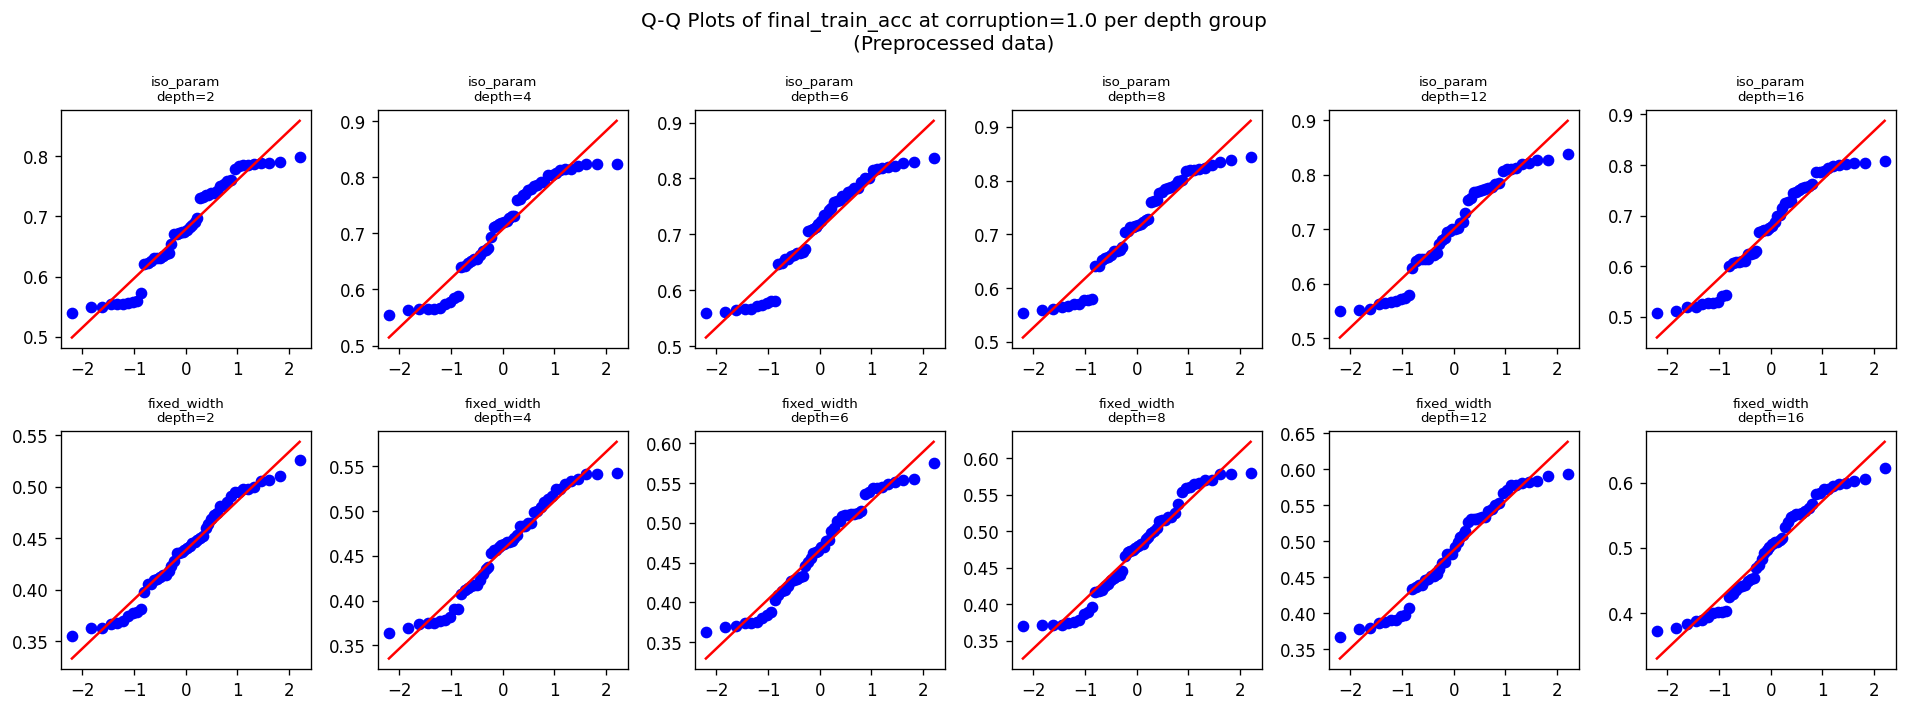

Q-Q plot saved.


In [ ]:
# ── Q-Q plots per depth group ─────────────────────────────────────────────────
fig, axes = plt.subplots(2, 6, figsize=(16, 6))
fig.suptitle('Q-Q Plots of final_train_acc at corruption=1.0 per depth group\n(Preprocessed data)', fontsize=12)

for row, (subset, label) in enumerate([(cap_iso, 'iso_param'), (cap_fixed, 'fixed_width')]):
    for col, d in enumerate(DEPTH_ORDER):
        ax = axes[row, col]
        vals = subset[subset['depth'] == d]['final_train_acc'].dropna()
        stats.probplot(vals, dist='norm', plot=ax)
        ax.set_title(f'{label}\ndepth={d}', fontsize=8)
        ax.set_xlabel('')
        ax.set_ylabel('')

plt.tight_layout()
plt.savefig('qq_plots_preprocessed.png', bbox_inches='tight')
plt.show()
print('Q-Q plot saved.')

---
## 4. Kruskal-Wallis Tests

**H₀:** All depth groups have the same distribution of `final_train_acc`  
**H₁:** At least one depth group differs  

η² = (H − k + 1) / (n − k); values ≥ 0.14 indicate large effects.

In [ ]:
def kruskal_wallis_with_eta(subset, label, dv='final_train_acc'):
    groups = [subset[subset['depth'] == d][dv].dropna().values for d in DEPTH_ORDER]
    H, p = kruskal(*groups)
    k = len(DEPTH_ORDER)
    n = sum(len(g) for g in groups)
    eta2 = (H - k + 1) / (n - k)
    print(f'[{label}]  H = {H:.4f},  df = {k-1},  p = {p:.6f},  η² = {eta2:.4f}')
    sig = 'SIGNIFICANT *' if p < 0.05 else 'not significant'
    print(f'  → {sig}')
    return H, p, eta2

print('=== Kruskal-Wallis: Effect of Depth on final_train_acc ===\n')
print('── Primary: corruption = 1.0 (capacity proxy) ──')
H_iso,   p_iso,   eta_iso   = kruskal_wallis_with_eta(cap_iso,   'iso_param  ')
H_fixed, p_fixed, eta_fixed = kruskal_wallis_with_eta(cap_fixed, 'fixed_width')

print('\n── Sensitivity: all corruption levels pooled ──')
kruskal_wallis_with_eta(df[df['regime']=='iso_param'],   'iso_param   (all corruption)')
kruskal_wallis_with_eta(df[df['regime']=='fixed_width'], 'fixed_width (all corruption)')

=== Kruskal-Wallis: Effect of Depth on final_train_acc ===

── Primary: corruption = 1.0 (capacity proxy) ──
[iso_param  ]  H = 8.7843,  df = 5,  p = 0.117982,  η² = 0.0129
  → not significant
[fixed_width]  H = 24.1480,  df = 5,  p = 0.000203,  η² = 0.0651
  → SIGNIFICANT *

── Sensitivity: all corruption levels pooled ──
[iso_param   (all corruption)]  H = 7.5523,  df = 5,  p = 0.182698,  η² = 0.0029
  → not significant
[fixed_width (all corruption)]  H = 19.3646,  df = 5,  p = 0.001644,  η² = 0.0161
  → SIGNIFICANT *


(np.float64(19.364561249566872),
 np.float64(0.0016435578341525085),
 np.float64(0.01606774188989583))

In [ ]:
# ── Kruskal-Wallis per corruption level (iso_param) ───────────────────────────
print('=== Kruskal-Wallis: iso_param — by corruption level ===\n')
print(f'{"corruption":>12}  {"H":>8}  {"p-value":>10}  {"η²":>6}  {"Sig?":>5}')
print('-' * 55)

iso_df = df[df['regime'] == 'iso_param']
for c in CORRUPTION_LEVELS:
    sub = iso_df[iso_df['corruption'] == c]
    groups = [sub[sub['depth'] == d]['final_train_acc'].dropna().values for d in DEPTH_ORDER]
    if any(len(g) == 0 for g in groups):
        print(f'{c:>12}  -- missing group --')
        continue
    H, p = kruskal(*groups)
    k, n = len(DEPTH_ORDER), sum(len(g) for g in groups)
    eta2 = (H - k + 1) / (n - k)
    sig = '*' if p < 0.05 else ''
    print(f'{c:>12}  {H:>8.3f}  {p:>10.4f}  {eta2:>6.4f}  {sig:>5}')

=== Kruskal-Wallis: iso_param — by corruption level ===

  corruption         H     p-value      η²   Sig?
-------------------------------------------------------
         0.0    15.750      0.0076  0.0366      *
         0.6    10.603      0.0598  0.0191       
         1.0     8.784      0.1180  0.0129       


---
## 5. Post-Hoc Pairwise Comparisons (Dunn's Test)

Kruskal-Wallis reveals *something* differs — Dunn's test identifies *which pairs*.  
Holm-Bonferroni correction controls family-wise error rate across C(6,2) = 15 pairwise comparisons.

In [ ]:
def run_dunn(subset, label):
    print(f'\n=== Dunn Post-Hoc (Holm correction) — {label} | corruption=1.0 ===')
    result = sp.posthoc_dunn(
        subset, val_col='final_train_acc', group_col='depth', p_adjust='holm'
    )
    result = result.loc[DEPTH_ORDER, DEPTH_ORDER]
    print('Adjusted p-values matrix (* = p < 0.05):')
    print(result.round(4))
    return result

dunn_iso   = run_dunn(cap_iso,   'iso_param')
dunn_fixed = run_dunn(cap_fixed, 'fixed_width')


=== Dunn Post-Hoc (Holm correction) — iso_param | corruption=1.0 ===
Adjusted p-values matrix (* = p < 0.05):
       2      4      6      8      12     16
2  1.0000 0.7185 0.7185 0.7185 1.0000 1.0000
4  0.7185 1.0000 1.0000 1.0000 1.0000 0.7185
6  0.7185 1.0000 1.0000 1.0000 1.0000 0.7185
8  0.7185 1.0000 1.0000 1.0000 1.0000 0.6918
12 1.0000 1.0000 1.0000 1.0000 1.0000 1.0000
16 1.0000 0.7185 0.7185 0.6918 1.0000 1.0000

=== Dunn Post-Hoc (Holm correction) — fixed_width | corruption=1.0 ===
Adjusted p-values matrix (* = p < 0.05):
       2      4      6      8      12     16
2  1.0000 0.9589 0.3013 0.0751 0.0022 0.0003
4  0.9589 1.0000 1.0000 1.0000 0.2325 0.0751
6  0.3013 1.0000 1.0000 1.0000 0.8524 0.3472
8  0.0751 1.0000 1.0000 1.0000 1.0000 0.9589
12 0.0022 0.2325 0.8524 1.0000 1.0000 1.0000
16 0.0003 0.0751 0.3472 0.9589 1.0000 1.0000


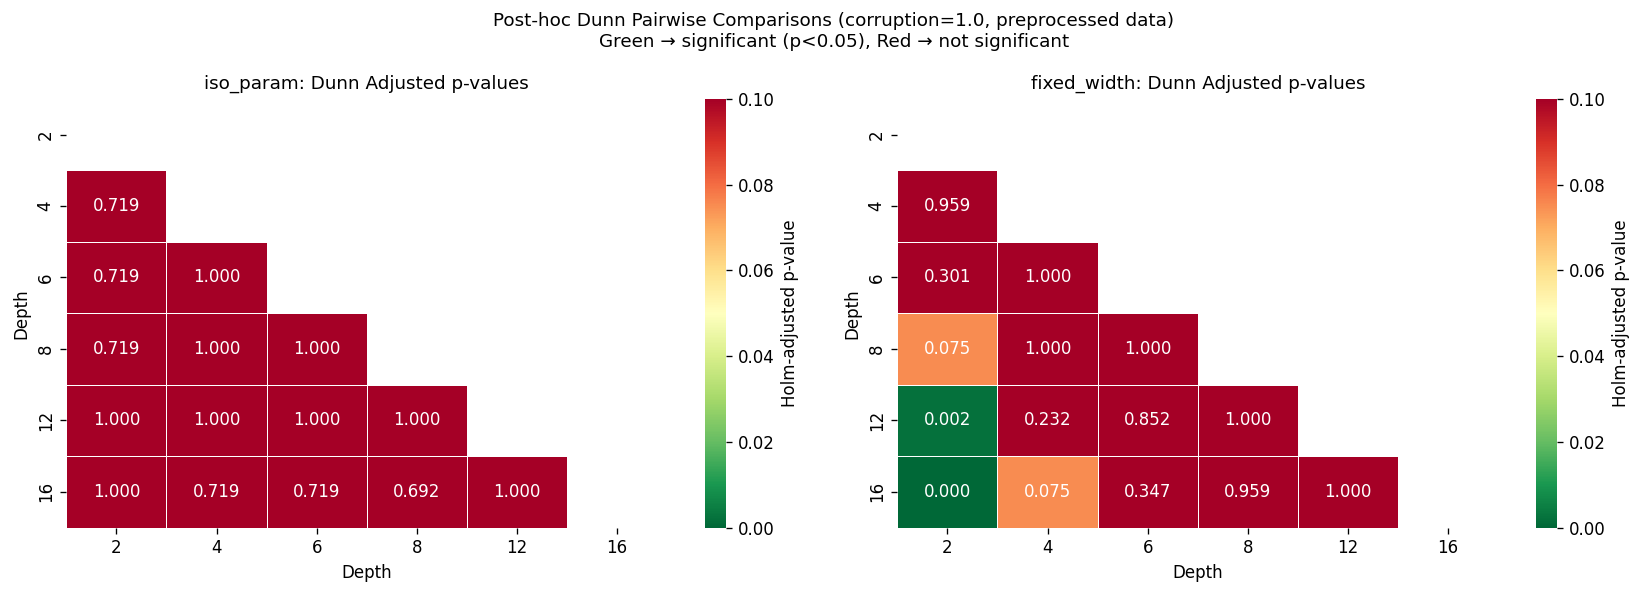

In [ ]:
# ── Heatmap of post-hoc p-values ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, dunn_result, title in zip(
    axes,
    [dunn_iso, dunn_fixed],
    ['iso_param: Dunn Adjusted p-values', 'fixed_width: Dunn Adjusted p-values']
):
    mask = np.triu(np.ones_like(dunn_result, dtype=bool))
    sns.heatmap(
        dunn_result, ax=ax, annot=True, fmt='.3f',
        cmap='RdYlGn_r', vmin=0, vmax=0.1,
        mask=mask, linewidths=0.5,
        cbar_kws={'label': 'Holm-adjusted p-value'}
    )
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Depth'); ax.set_ylabel('Depth')

plt.suptitle('Post-hoc Dunn Pairwise Comparisons (corruption=1.0, preprocessed data)\n'
             'Green → significant (p<0.05), Red → not significant', fontsize=11)
plt.tight_layout()
plt.savefig('dunn_heatmaps_preprocessed.png', bbox_inches='tight')
plt.show()

In [ ]:
# ── Rank-biserial effect sizes: depth 2 vs each deeper depth ─────────────────
def rank_biserial_r(x, y):
    n1, n2 = len(x), len(y)
    U, _ = mannwhitneyu(x, y, alternative='two-sided')
    return 1 - (2 * U) / (n1 * n2)

print('=== Pairwise: depth 2 vs deeper — rank-biserial r ===\n')
print(f'{"Contrast":>15}  {"Regime":>12}  {"r":>6}  magnitude')
print('-' * 55)

for (subset, label) in [(cap_iso, 'iso_param'), (cap_fixed, 'fixed_width')]:
    baseline = subset[subset['depth'] == 2]['final_train_acc'].values
    for d in [4, 6, 8, 12, 16]:
        target = subset[subset['depth'] == d]['final_train_acc'].values
        r = rank_biserial_r(baseline, target)
        mag = 'small' if abs(r) < 0.3 else ('medium' if abs(r) < 0.5 else 'large')
        print(f'  depth 2 vs {d:>2}  {label:>12}  {r:>6.3f}  {mag}')
    print()

=== Pairwise: depth 2 vs deeper — rank-biserial r ===

       Contrast        Regime       r  magnitude
-------------------------------------------------------
  depth 2 vs  4     iso_param   0.216  small
  depth 2 vs  6     iso_param   0.226  small
  depth 2 vs  8     iso_param   0.220  small
  depth 2 vs 12     iso_param   0.164  small
  depth 2 vs 16     iso_param  -0.036  small

  depth 2 vs  4   fixed_width   0.203  small
  depth 2 vs  6   fixed_width   0.273  small
  depth 2 vs  8   fixed_width   0.315  medium
  depth 2 vs 12   fixed_width   0.429  medium
  depth 2 vs 16   fixed_width   0.447  medium



---
## 6. OLS Regression: Effect of Depth Controlling for Confounders

Using `log_n_params` already computed by preprocessing (log₁₀ scale).

| Model | Formula |
|-------|---------|
| M1 | `final_train_acc ~ depth` |
| M2 | `final_train_acc ~ depth + log_n_params` |
| M3 | `final_train_acc ~ depth + log_n_params + param_err_pct` |
| M4 | `final_train_acc ~ depth * regime_code + log_n_params + param_err_pct` |

HC3 robust standard errors are used throughout (heteroscedasticity-consistent).

In [ ]:
# ── Regression dataset: corruption=1.0, fill structural NaN in param_err_pct ─
reg = cap.copy()
reg['param_err_pct'] = reg['param_err_pct'].fillna(0)   # NaN = fixed_width (no budget constraint)
reg['high_param_err'] = reg['param_err_pct'] > 2.0

print('Regression dataset shape:', reg.shape)
print('\nDescriptive stats for key regression variables:')
reg[['final_train_acc','depth','log_n_params','param_err_pct','regime_code']].describe().round(4)

Regression dataset shape: (600, 32)

Descriptive stats for key regression variables:


,final_train_acc,depth,log_n_params,param_err_pct,regime_code
count,600.0000,600.0000,600.0000,600.0000,600.0000
mean,0.5831,8.0000,4.3100,0.9353,0.5000
std,0.1381,4.7649,0.1790,1.4565,0.5004
min,0.3553,2.0000,3.9892,0.0000,0.0000
25%,0.4698,4.0000,4.1684,0.0000,0.0000
50%,0.5619,7.0000,4.2840,0.0217,0.5000
75%,0.7073,12.0000,4.4673,1.3171,1.0000
max,0.8448,16.0000,4.6005,6.7050,1.0000


In [ ]:
formulas = {
    'M1 (depth only)':
        'final_train_acc ~ depth',
    'M2 (+ log_n_params)':
        'final_train_acc ~ depth + log_n_params',
    'M3 (+ param_err_pct)':
        'final_train_acc ~ depth + log_n_params + param_err_pct',
    'M4 (+ regime interaction)':
        'final_train_acc ~ depth * regime_code + log_n_params + param_err_pct',
}

models = {}
for name, formula in formulas.items():
    m = smf.ols(formula, data=reg).fit(cov_type='HC3')
    models[name] = m
    print(f'\n{"="*60}')
    print(f'  {name}')
    print(f'{"="*60}')
    print(m.summary2().tables[1])
    print(f'  R² = {m.rsquared:.4f}  |  Adj. R² = {m.rsquared_adj:.4f}  |  AIC = {m.aic:.2f}')


  M1 (depth only)
           Coef.  Std.Err.       z  P>|z|  [0.025  0.975]
Intercept 0.5714    0.0111 51.3466 0.0000  0.5496  0.5932
depth     0.0015    0.0011  1.2888 0.1975 -0.0008  0.0037
  R² = 0.0026  |  Adj. R² = 0.0009  |  AIC = -671.31

  M2 (+ log_n_params)
               Coef.  Std.Err.         z  P>|z|  [0.025  0.975]
Intercept    -2.7198    0.0185 -147.1379 0.0000 -2.7561 -2.6836
depth        -0.0016    0.0002   -9.7035 0.0000 -0.0019 -0.0013
log_n_params  0.7693    0.0044  175.3623 0.0000  0.7607  0.7779
  R² = 0.9850  |  Adj. R² = 0.9850  |  AIC = -3189.19

  M3 (+ param_err_pct)
                Coef.  Std.Err.         z  P>|z|  [0.025  0.975]
Intercept     -2.7217    0.0200 -135.9561 0.0000 -2.7609 -2.6825
depth         -0.0016    0.0002   -9.3796 0.0000 -0.0019 -0.0013
log_n_params   0.7698    0.0048  162.0183 0.0000  0.7605  0.7791
param_err_pct -0.0001    0.0005   -0.2907 0.7713 -0.0012  0.0009
  R² = 0.9850  |  Adj. R² = 0.9850  |  AIC = -3187.27

  M4 (+ regime in

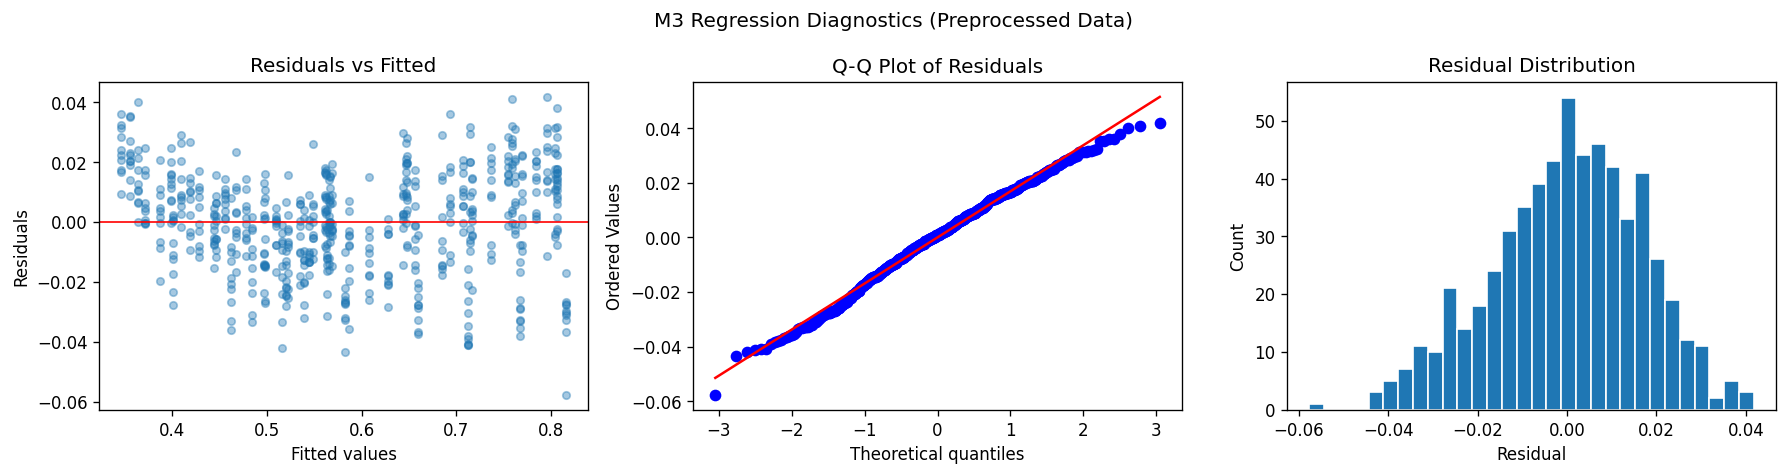


Shapiro-Wilk on M3 residuals: W=0.9902, p=0.1917 → Normal
Note: HC3 robust SEs used — non-normality of residuals is less critical.


In [ ]:
# ── M3 diagnostic plots ───────────────────────────────────────────────────────
m3    = models['M3 (+ param_err_pct)']
resid = m3.resid
fitted = m3.fittedvalues

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('M3 Regression Diagnostics (Preprocessed Data)', fontsize=12)

axes[0].scatter(fitted, resid, alpha=0.4, s=20)
axes[0].axhline(0, color='red', lw=1)
axes[0].set_xlabel('Fitted values'); axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Fitted')

stats.probplot(resid, dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot of Residuals')

axes[2].hist(resid, bins=30, edgecolor='white')
axes[2].set_xlabel('Residual'); axes[2].set_ylabel('Count')
axes[2].set_title('Residual Distribution')

plt.tight_layout()
plt.savefig('regression_diagnostics_preprocessed.png', bbox_inches='tight')
plt.show()

W_r, p_r = shapiro(resid.sample(min(len(resid), 200), random_state=42))
print(f'\nShapiro-Wilk on M3 residuals: W={W_r:.4f}, p={p_r:.4f}',
      '→ Non-normal *' if p_r < 0.05 else '→ Normal')
print('Note: HC3 robust SEs used — non-normality of residuals is less critical.')

In [ ]:
# ── VIF check ─────────────────────────────────────────────────────────────────
X_vif = sm.add_constant(reg[['depth', 'log_n_params', 'param_err_pct']].dropna())
vif_df = pd.DataFrame({
    'Variable': X_vif.columns,
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
})
print('Variance Inflation Factors (M3 predictors):')
print(vif_df.to_string(index=False))
print('\nRule of thumb: VIF > 5 suggests problematic multicollinearity.')

Variance Inflation Factors (M3 predictors):
     Variable      VIF
        const 675.4359
        depth   1.0726
 log_n_params   1.1814
param_err_pct   1.2528

Rule of thumb: VIF > 5 suggests problematic multicollinearity.


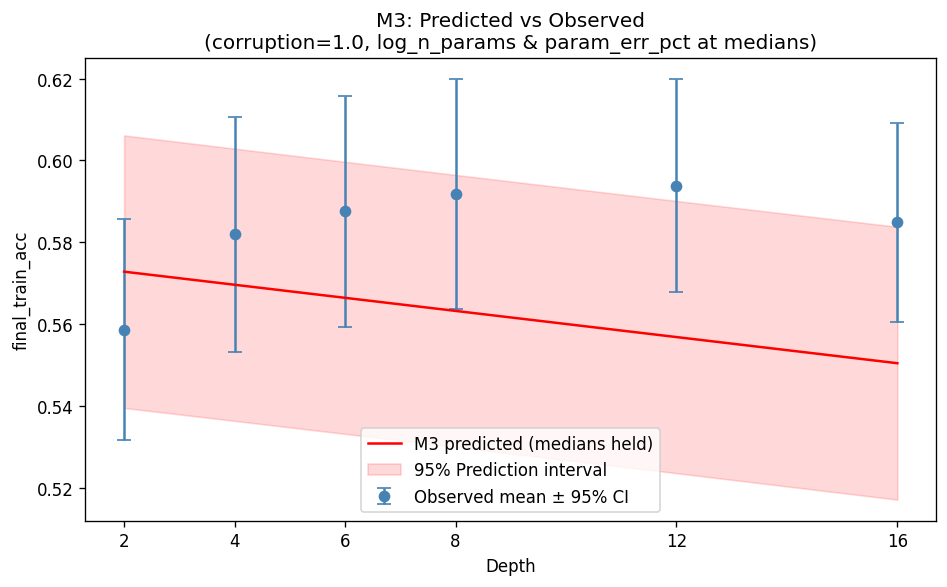

In [ ]:
# ── M3 predicted vs observed ──────────────────────────────────────────────────
median_log_n = reg['log_n_params'].median()
median_err   = reg['param_err_pct'].median()

pred_df  = pd.DataFrame({'depth': DEPTH_ORDER,
                          'log_n_params': median_log_n,
                          'param_err_pct': median_err})
pred     = m3.get_prediction(pred_df)
pred_ci  = pred.summary_frame(alpha=0.05)
obs_means = reg.groupby('depth')['final_train_acc'].agg(['mean','sem']).reset_index()

plt.figure(figsize=(8, 5))
plt.errorbar(obs_means['depth'], obs_means['mean'], yerr=obs_means['sem']*1.96,
             fmt='o', color='steelblue', label='Observed mean ± 95% CI', capsize=4)
plt.plot(pred_df['depth'], pred_ci['mean'], 'r-', label='M3 predicted (medians held)')
plt.fill_between(pred_df['depth'], pred_ci['obs_ci_lower'], pred_ci['obs_ci_upper'],
                 alpha=0.15, color='red', label='95% Prediction interval')
plt.xlabel('Depth'); plt.ylabel('final_train_acc')
plt.title('M3: Predicted vs Observed\n(corruption=1.0, log_n_params & param_err_pct at medians)')
plt.legend(); plt.xticks(DEPTH_ORDER)
plt.tight_layout()
plt.savefig('regression_predicted_preprocessed.png', bbox_inches='tight')
plt.show()

In [ ]:
# ── Sensitivity: M3 on clean subset (param_err_pct ≤ 2%) ─────────────────────
print('=== M3 Sensitivity Check: clean subset (param_err_pct ≤ 2%) ===')
reg_clean = reg[~reg['high_param_err']]
m3_clean = smf.ols(
    'final_train_acc ~ depth + log_n_params + param_err_pct',
    data=reg_clean
).fit(cov_type='HC3')
print(m3_clean.summary2().tables[1])
print(f'\nR² = {m3_clean.rsquared:.4f}  |  n = {int(m3_clean.nobs)}')
print('\nIf depth coefficient is similar to M3 on full data → result is robust.')

=== M3 Sensitivity Check: clean subset (param_err_pct ≤ 2%) ===
                Coef.  Std.Err.        z  P>|z|  [0.025  0.975]
Intercept     -2.6589    0.0268 -99.2136 0.0000 -2.7114 -2.6063
depth         -0.0016    0.0002  -8.4526 0.0000 -0.0020 -0.0012
log_n_params   0.7547    0.0064 117.6752 0.0000  0.7421  0.7672
param_err_pct  0.0068    0.0019   3.5572 0.0004  0.0031  0.0106

R² = 0.9859  |  n = 490

If depth coefficient is similar to M3 on full data → result is robust.


---
## 7. Supporting Tests

### 7a. Regime Comparison: iso_param vs fixed_width at depth 16
### 7b. Spearman Correlation (depth × train_acc) per corruption level
### 7c. Budget Interaction (iso_param only)

In [ ]:
# ── 7a. Mann-Whitney: iso_param vs fixed_width at depth=16 ───────────────────
print('=== 7a. Mann-Whitney: iso_param vs fixed_width at depth=16, corruption=1.0 ===\n')
iso_d16   = cap_iso[cap_iso['depth']   == 16]['final_train_acc'].dropna()
fixed_d16 = cap_fixed[cap_fixed['depth'] == 16]['final_train_acc'].dropna()

U, p_mw = mannwhitneyu(iso_d16, fixed_d16, alternative='two-sided')
r_mw = rank_biserial_r(iso_d16.values, fixed_d16.values)

print(f'iso_param   depth=16:  n={len(iso_d16)},  median={iso_d16.median():.4f}')
print(f'fixed_width depth=16:  n={len(fixed_d16)},  median={fixed_d16.median():.4f}')
print(f'\nMann-Whitney U = {U:.0f},  p = {p_mw:.4f},  rank-biserial r = {r_mw:.3f}')
print('Interpretation: positive r → iso_param tends to score LOWER (capacity disadvantage)')

=== 7a. Mann-Whitney: iso_param vs fixed_width at depth=16, corruption=1.0 ===

iso_param   depth=16:  n=50,  median=0.6777
fixed_width depth=16:  n=50,  median=0.5035

Mann-Whitney U = 2290,  p = 0.0000,  rank-biserial r = -0.832
Interpretation: positive r → iso_param tends to score LOWER (capacity disadvantage)


In [ ]:
# ── 7b. Spearman: depth × final_train_acc, per corruption × regime ────────────
print('=== 7b. Spearman Correlations: depth vs final_train_acc ===\n')
print(f'{"corruption":>12}  {"regime":>12}  {"r":>7}  {"p-value":>10}  {"Sig?":>5}')
print('-' * 57)

for regime in ['iso_param', 'fixed_width']:
    for c in CORRUPTION_LEVELS:
        sub = df[(df['regime'] == regime) & (df['corruption'] == c)]
        if len(sub) < 5:
            continue
        r, p = spearmanr(sub['depth'], sub['final_train_acc'])
        sig = '*' if p < 0.05 else ''
        print(f'{c:>12}  {regime:>12}  {r:>7.4f}  {p:>10.4f}  {sig:>5}')
    print()

=== 7b. Spearman Correlations: depth vs final_train_acc ===

  corruption        regime        r     p-value   Sig?
---------------------------------------------------------
         0.0     iso_param  -0.1660      0.0039      *
         0.6     iso_param  -0.0172      0.7662       
         1.0     iso_param  -0.0184      0.7514       

         0.0   fixed_width   0.2957      0.0000      *
         0.6   fixed_width   0.3323      0.0000      *
         1.0   fixed_width   0.2804      0.0000      *



In [ ]:
# ── 7c. Budget interaction: depth × budget (iso_param, corruption=1.0) ────────
iso_reg = df[(df['regime'] == 'iso_param') & (df['corruption'] == 1.0)].copy()
iso_reg['budget_cat'] = iso_reg['budget'].map({
    20_000: '20k',
    25_000: '25k',
    30_000: '30k',
    35_000: '35k',
    40_000: '40k',
})
iso_reg['param_err_pct'] = iso_reg['param_err_pct'].fillna(0)

print('=== 7c. Budget Interaction (iso_param, corruption=1.0) ===')
m_budget = smf.ols(
    'final_train_acc ~ depth * C(budget_cat) + param_err_pct',
    data=iso_reg
).fit(cov_type='HC3')
print(m_budget.summary2().tables[1])
print(f'\nR² = {m_budget.rsquared:.4f}  |  n = {int(m_budget.nobs)}')
print('\nSignificant depth:budget interaction → depth effect depends on budget size.')

=== 7c. Budget Interaction (iso_param, corruption=1.0) ===
                             Coef.  Std.Err.        z  P>|z|  [0.025  0.975]
Intercept                   0.5879    0.0057 102.2765 0.0000  0.5766  0.5991
C(budget_cat)[T.25k]        0.0720    0.0078   9.2838 0.0000  0.0568  0.0872
C(budget_cat)[T.30k]        0.1256    0.0074  17.0155 0.0000  0.1112  0.1401
C(budget_cat)[T.35k]        0.1810    0.0074  24.4643 0.0000  0.1665  0.1955
C(budget_cat)[T.40k]        0.2235    0.0079  28.3317 0.0000  0.2080  0.2389
depth                      -0.0008    0.0005  -1.6841 0.0922 -0.0018  0.0001
depth:C(budget_cat)[T.25k] -0.0001    0.0007  -0.1580 0.8744 -0.0015  0.0013
depth:C(budget_cat)[T.30k]  0.0011    0.0007   1.6178 0.1057 -0.0002  0.0025
depth:C(budget_cat)[T.35k]  0.0014    0.0007   2.0494 0.0404  0.0001  0.0027
depth:C(budget_cat)[T.40k]  0.0018    0.0007   2.5483 0.0108  0.0004  0.0033
param_err_pct              -0.0064    0.0009  -7.5199 0.0000 -0.0081 -0.0048

R² = 0.9662  |  

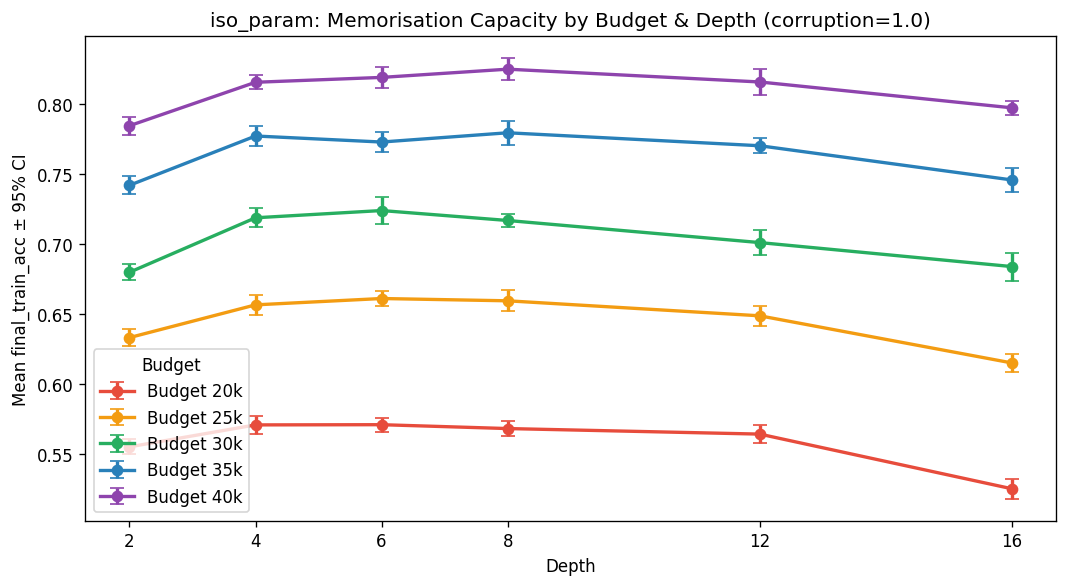

In [ ]:
# Visualise budget × depth interaction
budget_means = iso_reg.groupby(['budget_cat','depth'])['final_train_acc'].agg(['mean','sem']).reset_index()
colors = {'20k': '#e74c3c', '25k': '#f39c12', '30k': '#27ae60',
          '35k': '#2980b9', '40k': '#8e44ad'}

plt.figure(figsize=(9, 5))
for b, grp in budget_means.groupby('budget_cat'):
    plt.errorbar(grp['depth'], grp['mean'], yerr=grp['sem']*1.96,
                 fmt='-o', label=f'Budget {b}', color=colors.get(b, 'grey'),
                 capsize=4, linewidth=2)
plt.xlabel('Depth'); plt.ylabel('Mean final_train_acc ± 95% CI')
plt.title('iso_param: Memorisation Capacity by Budget & Depth (corruption=1.0)')
plt.legend(title='Budget'); plt.xticks(DEPTH_ORDER)
plt.tight_layout()
plt.savefig('budget_depth_interaction_preprocessed.png', bbox_inches='tight')
plt.show()

---
## 8. Summary Table of All Inferential Results

In [ ]:
m3_coef = models['M3 (+ param_err_pct)'].params['depth']
m3_pval = models['M3 (+ param_err_pct)'].pvalues['depth']
m3_ci   = models['M3 (+ param_err_pct)'].conf_int().loc['depth']

m4_coef = models['M4 (+ regime interaction)'].params['depth']
m4_pval = models['M4 (+ regime interaction)'].pvalues['depth']

kw_rows = [
    ('Kruskal-Wallis', 'iso_param',   'depth → train_acc', 'corruption=1.0',
     f'H={H_iso:.3f}',   f'p={p_iso:.5f}',   f'η²={eta_iso:.4f}'),
    ('Kruskal-Wallis', 'fixed_width', 'depth → train_acc', 'corruption=1.0',
     f'H={H_fixed:.3f}', f'p={p_fixed:.5f}', f'η²={eta_fixed:.4f}'),
]

reg_rows = [
    ('OLS M3', 'both',       'depth → train_acc',          'corruption=1.0',
     f'β={m3_coef:.4f}',     f'p={m3_pval:.5f}', f'95%CI [{m3_ci[0]:.4f},{m3_ci[1]:.4f}]'),
    ('OLS M4', 'both',       'depth*regime → train_acc',   'corruption=1.0',
     f'β_depth={m4_coef:.4f}', f'p={m4_pval:.5f}', 'see interaction terms'),
    ('Mann-Whitney', 'both', 'iso vs fixed at depth=16',   'corruption=1.0',
     f'U={U:.0f}',          f'p={p_mw:.4f}',     f'r={r_mw:.3f}'),
]

summary = pd.DataFrame(kw_rows + reg_rows,
                       columns=['Test','Regime','Comparison','Subset','Statistic','p-value','Effect Size'])
print('\n=== INFERENTIAL RESULTS SUMMARY (Preprocessed Data) ===')
print(summary.to_string(index=False))


=== INFERENTIAL RESULTS SUMMARY (Preprocessed Data) ===
          Test      Regime               Comparison         Subset      Statistic   p-value             Effect Size
Kruskal-Wallis   iso_param        depth → train_acc corruption=1.0        H=8.784 p=0.11798               η²=0.0129
Kruskal-Wallis fixed_width        depth → train_acc corruption=1.0       H=24.148 p=0.00020               η²=0.0651
        OLS M3        both        depth → train_acc corruption=1.0      β=-0.0016 p=0.00000 95%CI [-0.0019,-0.0013]
        OLS M4        both depth*regime → train_acc corruption=1.0 β_depth=0.0001 p=0.62211   see interaction terms
  Mann-Whitney        both iso vs fixed at depth=16 corruption=1.0         U=2290  p=0.0000                r=-0.832


In [ ]:
# ── Model comparison (AIC / R²) ───────────────────────────────────────────────
model_comp = pd.DataFrame([
    {'Model': name, 'n': int(m.nobs),
     'R²': round(m.rsquared, 4), 'Adj. R²': round(m.rsquared_adj, 4),
     'AIC': round(m.aic, 2),     'BIC': round(m.bic, 2)}
    for name, m in models.items()
])
print('\n=== OLS MODEL COMPARISON ===')
print(model_comp.to_string(index=False))
print('\nLower AIC/BIC = better fit penalised for complexity.')


=== OLS MODEL COMPARISON ===
                    Model   n     R²  Adj. R²        AIC        BIC
          M1 (depth only) 600 0.0026   0.0009  -671.3100  -662.5100
      M2 (+ log_n_params) 600 0.9850   0.9850 -3189.1900 -3176.0000
     M3 (+ param_err_pct) 600 0.9850   0.9850 -3187.2700 -3169.6800
M4 (+ regime interaction) 600 0.9873   0.9872 -3280.5800 -3254.1900

Lower AIC/BIC = better fit penalised for complexity.
